<a href="https://colab.research.google.com/github/Dinusha-Ekanayake/DataExplore_Stage_01/blob/main/DataExplore_Stage_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('healthcare_data.csv')
df = df.drop(columns=['Unnamed: 0'])  # drop the extra index column

In [3]:
print(df.shape)           # rows and columns
print(df.dtypes)          # data types
print(df.head())          # first 5 rows
print(df.isnull().sum())  # missing values per column
print(df.duplicated().sum())  # duplicate rows

(9722, 17)
patient_id             int64
gender                object
age                  float64
has_hypertension       int64
has_heart_disease      int64
marital_status         int64
employment_type       object
residence             object
glucose_level        float64
bmi_value            float64
smoking_habit         object
stroke_event           int64
age_group             object
risk_score             int64
high_glucose           int64
bmi_category          object
lifestyle_risk        object
dtype: object
   patient_id gender   age  has_hypertension  has_heart_disease  \
0       30669      M   3.0                 0                  0   
1       30468      M  58.0                 1                  0   
2       16523      F   8.0                 0                  0   
3       56543      F  70.0                 0                  0   
4       46136      M  14.0                 0                  0   

   marital_status employment_type residence  glucose_level  bmi_value  \
0     

In [4]:
print(f"Before: {df.shape}")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

Before: (9722, 17)
After removing duplicates: (5110, 17)


In [5]:
# Check if missingness is related to stroke (important insight!)
print(df.groupby('stroke_event')['bmi_value'].apply(lambda x: x.isnull().sum()))

# Fill with median (safer than mean for skewed health data)
df['bmi_value'].fillna(df['bmi_value'].median(), inplace=True)

print(f"Missing bmi_value after fix: {df['bmi_value'].isnull().sum()}")

stroke_event
0    161
1     40
Name: bmi_value, dtype: int64
Missing bmi_value after fix: 0


/tmp/ipykernel_1323/362256160.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi_value'].fillna(df['bmi_value'].median(), inplace=True)


In [6]:
print(df.isnull().sum().sum())   # should be 0
print(df.duplicated().sum())     # should be 0
print(df.shape)                  # final shape after cleaning

0
0
(5110, 17)


In [7]:
print(df['stroke_event'].value_counts())
print(df['stroke_event'].value_counts(normalize=True) * 100)

stroke_event
0    4861
1     249
Name: count, dtype: int64
stroke_event
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [8]:
# Numerical summary
print(df[['age', 'glucose_level', 'bmi_value', 'risk_score']].describe().round(2))

# Stroke rate by key groups
for col in ['gender', 'has_hypertension', 'has_heart_disease', 'age_group', 'bmi_category', 'smoking_habit']:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['stroke_event'].mean().mul(100).round(2).astype(str) + '%')

           age  glucose_level  bmi_value  risk_score
count  5110.00        5110.00    5110.00     5110.00
mean     43.23         106.15      28.86        0.15
std      22.61          45.28       7.70        0.39
min       0.08          55.12      10.30        0.00
25%      25.00          77.24      23.80        0.00
50%      45.00          91.88      28.10        0.00
75%      61.00         114.09      32.80        0.00
max      82.00         271.74      97.60        2.00

--- gender ---
gender
F    4.71%
M    5.11%
Name: stroke_event, dtype: object

--- has_hypertension ---
has_hypertension
0     3.97%
1    13.25%
Name: stroke_event, dtype: object

--- has_heart_disease ---
has_heart_disease
0     4.18%
1    17.03%
Name: stroke_event, dtype: object

--- age_group ---
age_group
middle     2.97%
senior    13.15%
young      0.13%
Name: stroke_event, dtype: object

--- bmi_category ---
bmi_category
normal         2.82%
obese          6.51%
overweight     5.32%
underweight     0.3%
Name: s

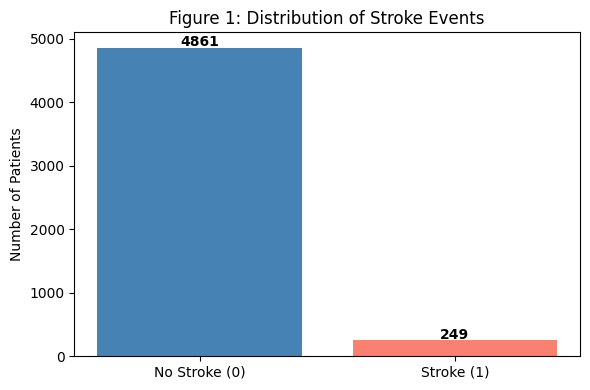

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))
counts = df['stroke_event'].value_counts()
ax.bar(['No Stroke (0)', 'Stroke (1)'], counts.values, color=['steelblue', 'salmon'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
ax.set_title('Figure 1: Distribution of Stroke Events')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('fig1_stroke_distribution.png', dpi=150)
plt.show()

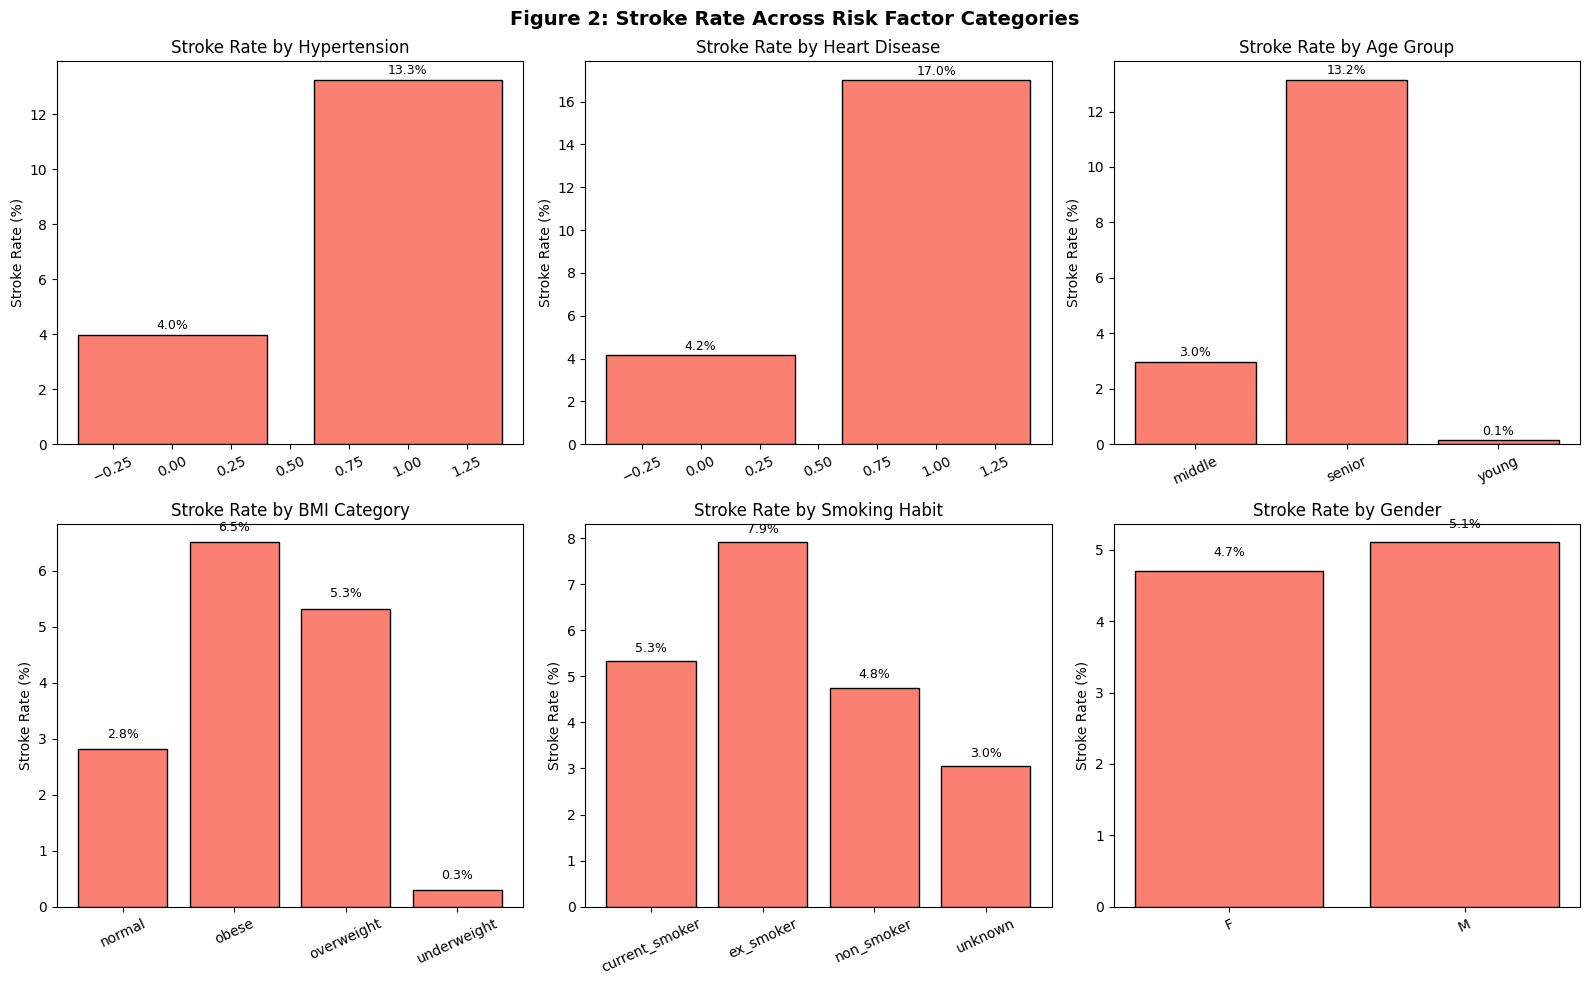

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cat_cols = ['has_hypertension', 'has_heart_disease', 'age_group',
            'bmi_category', 'smoking_habit', 'gender']
labels = ['Hypertension', 'Heart Disease', 'Age Group',
          'BMI Category', 'Smoking Habit', 'Gender']

for ax, col, label in zip(axes.flatten(), cat_cols, labels):
    stroke_rate = df.groupby(col)['stroke_event'].mean() * 100
    bars = ax.bar(stroke_rate.index, stroke_rate.values, color='salmon', edgecolor='black')
    for bar, val in zip(bars, stroke_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Stroke Rate by {label}')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Figure 2: Stroke Rate Across Risk Factor Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_stroke_by_categories.png', dpi=150)
plt.show()

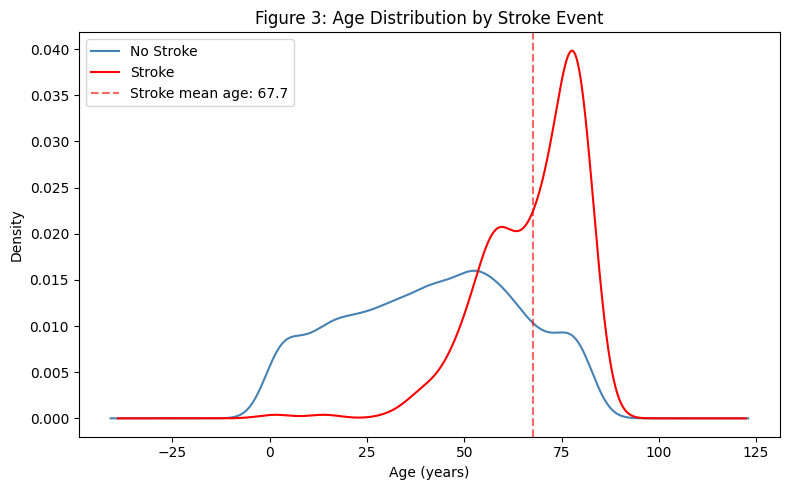

Mean age - Stroke: 67.7
Mean age - No Stroke: 42.0


In [11]:
plt.figure(figsize=(8,5))
df[df['stroke_event']==0]['age'].plot(kind='kde', label='No Stroke', color='steelblue')
df[df['stroke_event']==1]['age'].plot(kind='kde', label='Stroke', color='red')
plt.axvline(df[df['stroke_event']==1]['age'].mean(), color='red', linestyle='--', alpha=0.6,
            label=f"Stroke mean age: {df[df['stroke_event']==1]['age'].mean():.1f}")
plt.title('Figure 3: Age Distribution by Stroke Event')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig3_age_distribution.png', dpi=150)
plt.show()

# Print mean ages for your report
print("Mean age - Stroke:", df[df['stroke_event']==1]['age'].mean().round(1))
print("Mean age - No Stroke:", df[df['stroke_event']==0]['age'].mean().round(1))

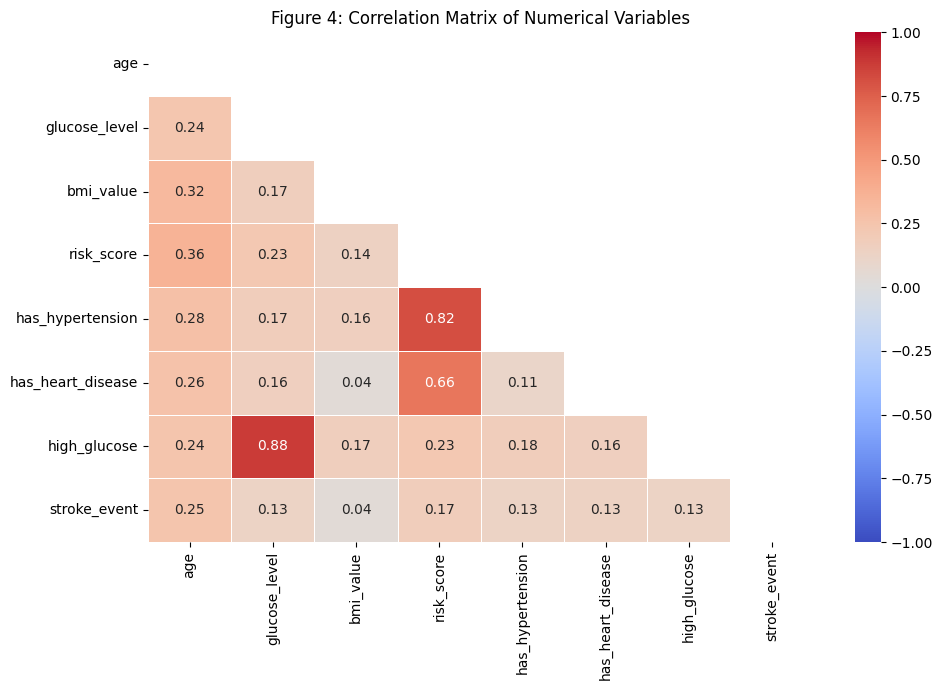

In [12]:
plt.figure(figsize=(10,7))
num_cols = ['age', 'glucose_level', 'bmi_value', 'risk_score',
            'has_hypertension', 'has_heart_disease', 'high_glucose', 'stroke_event']
corr = df[num_cols].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # show only lower triangle
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Figure 4: Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150)
plt.show()

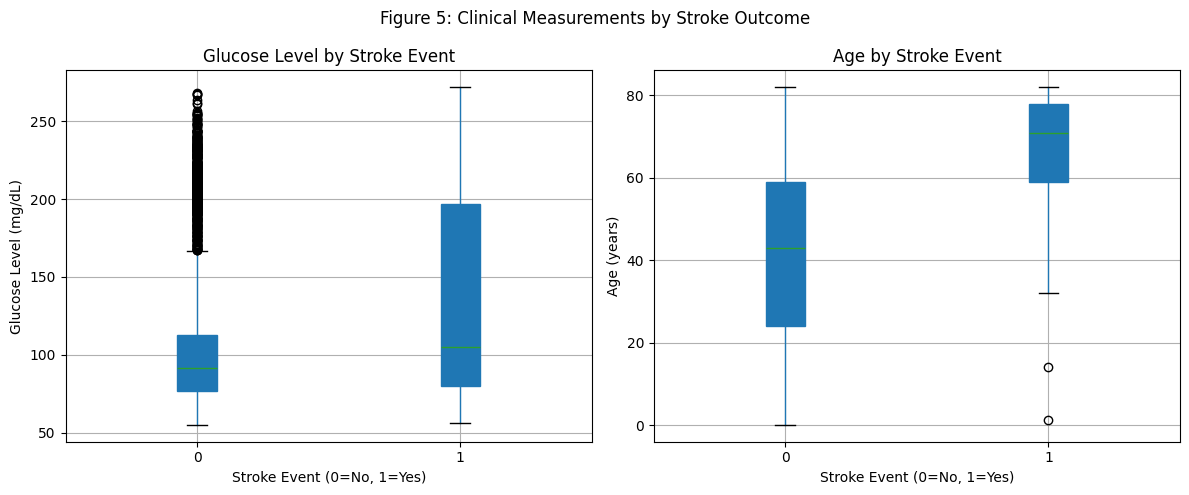

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='glucose_level', by='stroke_event', ax=axes[0],
           patch_artist=True)
axes[0].set_title('Glucose Level by Stroke Event')
axes[0].set_xlabel('Stroke Event (0=No, 1=Yes)')
axes[0].set_ylabel('Glucose Level (mg/dL)')

df.boxplot(column='age', by='stroke_event', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Age by Stroke Event')
axes[1].set_xlabel('Stroke Event (0=No, 1=Yes)')
axes[1].set_ylabel('Age (years)')

plt.suptitle('Figure 5: Clinical Measurements by Stroke Outcome')
plt.tight_layout()
plt.savefig('fig5_boxplots.png', dpi=150)
plt.show()

In [14]:
from scipy import stats

stroke_age = df[df['stroke_event']==1]['age']
no_stroke_age = df[df['stroke_event']==0]['age']

t_stat, p_val = stats.ttest_ind(stroke_age, no_stroke_age)
print(f"Age T-test: t={t_stat:.3f}, p={p_val:.6f}")
print("Significant?" , "YES" if p_val < 0.05 else "NO")

Age T-test: t=18.081, p=0.000000
Significant? YES


In [15]:
stroke_gluc = df[df['stroke_event']==1]['glucose_level']
no_stroke_gluc = df[df['stroke_event']==0]['glucose_level']

t_stat2, p_val2 = stats.ttest_ind(stroke_gluc, no_stroke_gluc)
print(f"Glucose T-test: t={t_stat2:.3f}, p={p_val2:.6f}")
print("Significant?", "YES" if p_val2 < 0.05 else "NO")
print(f"Mean glucose - Stroke: {stroke_gluc.mean():.2f}")
print(f"Mean glucose - No Stroke: {no_stroke_gluc.mean():.2f}")

Glucose T-test: t=9.513, p=0.000000
Significant? YES
Mean glucose - Stroke: 132.54
Mean glucose - No Stroke: 104.80


In [16]:
from scipy.stats import chi2_contingency

for col in ['has_hypertension', 'has_heart_disease', 'high_glucose']:
    ct = pd.crosstab(df[col], df['stroke_event'])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"\n{col}: chi2={chi2:.3f}, p={p:.6f}, Significant: {'YES' if p < 0.05 else 'NO'}")


has_hypertension: chi2=81.605, p=0.000000, Significant: YES

has_heart_disease: chi2=90.260, p=0.000000, Significant: YES

high_glucose: chi2=86.271, p=0.000000, Significant: YES


Model Development

In [17]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

cat_cols = ['gender', 'employment_type', 'residence',
            'smoking_habit', 'age_group', 'bmi_category', 'lifestyle_risk']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['patient_id', 'stroke_event'])
y = df_model['stroke_event']

print("Features shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Features shape: (5110, 15)
Class distribution:
 stroke_event
0    4861
1     249
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Stroke cases in test set: {y_test.sum()}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE - Train class distribution:\n{pd.Series(y_train_res).value_counts()}")

# Scale
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

Train size: 4088, Test size: 1022
Stroke cases in test set: 50

After SMOTE - Train class distribution:
stroke_event
0    3889
1    3889
Name: count, dtype: int64


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n{'='*40}")
    print(f"{name}  |  AUC-ROC: {auc:.4f}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=['No Stroke','Stroke']))


Logistic Regression  |  AUC-ROC: 0.7644
              precision    recall  f1-score   support

   No Stroke       0.97      0.82      0.89       972
      Stroke       0.13      0.54      0.21        50

    accuracy                           0.80      1022
   macro avg       0.55      0.68      0.55      1022
weighted avg       0.93      0.80      0.85      1022


Random Forest  |  AUC-ROC: 0.7713
              precision    recall  f1-score   support

   No Stroke       0.96      0.96      0.96       972
      Stroke       0.17      0.16      0.16        50

    accuracy                           0.92      1022
   macro avg       0.56      0.56      0.56      1022
weighted avg       0.92      0.92      0.92      1022


Gradient Boosting  |  AUC-ROC: 0.7695
              precision    recall  f1-score   support

   No Stroke       0.96      0.89      0.93       972
      Stroke       0.15      0.36      0.21        50

    accuracy                           0.87      1022
   macro avg 

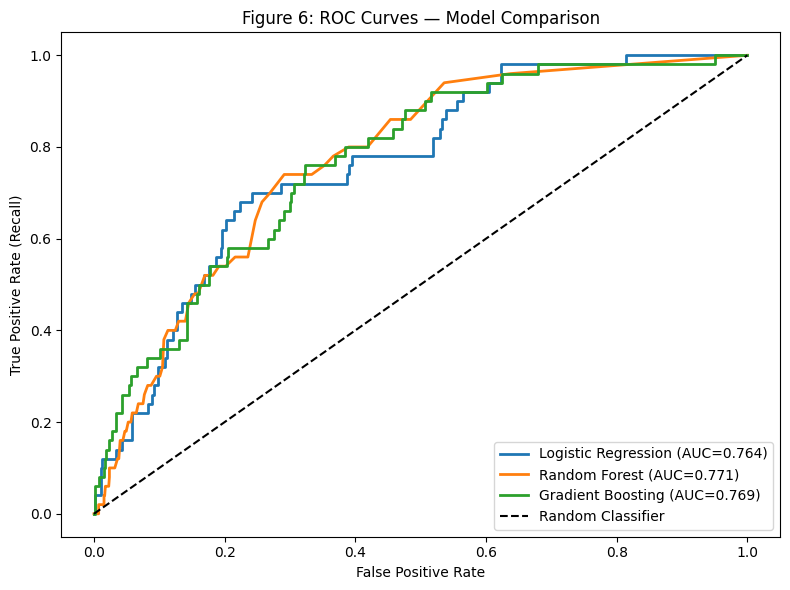

In [20]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Figure 6: ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig6_roc_curves.png', dpi=150)
plt.show()

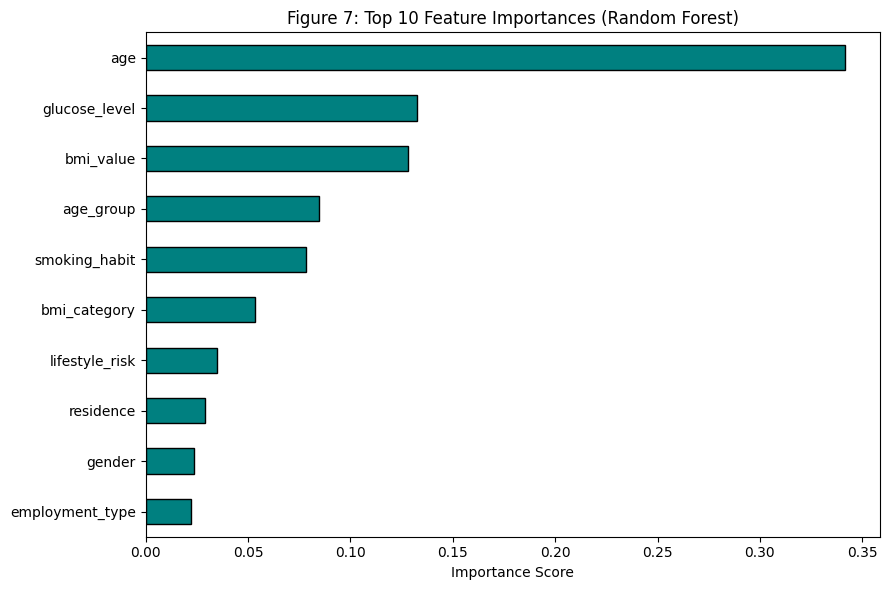


All feature importances:
age                  0.3416
glucose_level        0.1324
bmi_value            0.1279
age_group            0.0847
smoking_habit        0.0784
bmi_category         0.0535
lifestyle_risk       0.0350
residence            0.0288
gender               0.0234
employment_type      0.0223
marital_status       0.0215
high_glucose         0.0187
has_hypertension     0.0119
risk_score           0.0103
has_heart_disease    0.0096
dtype: float64


In [21]:
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9,6))
feat_imp.tail(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Figure 7: Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150)
plt.show()

print("\nAll feature importances:")
print(feat_imp.sort_values(ascending=False).round(4))

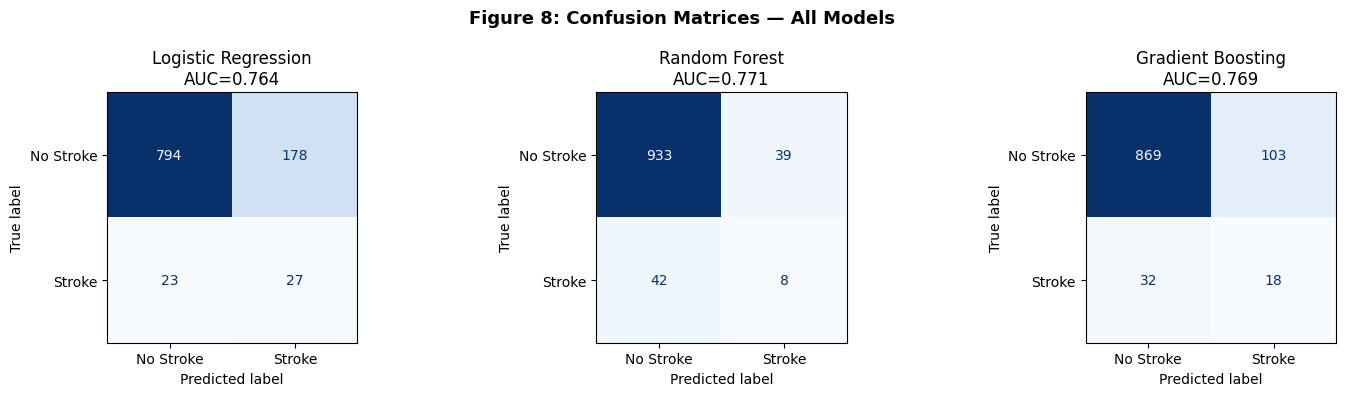

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Run for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f}')

plt.suptitle('Figure 8: Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_confusion_matrices.png', dpi=150)
plt.show()

Tune Gradient Boosting & Get Final Results

Tune the Best Model

In [23]:
from sklearn.model_selection import cross_val_score

gb_tuned = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

gb_tuned.fit(X_train_res, y_train_res)
y_pred_tuned = gb_tuned.predict(X_test_scaled)
y_prob_tuned = gb_tuned.predict_proba(X_test_scaled)[:, 1]

print("=== Tuned Gradient Boosting ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No Stroke','Stroke']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

=== Tuned Gradient Boosting ===
              precision    recall  f1-score   support

   No Stroke       0.96      0.92      0.94       972
      Stroke       0.15      0.28      0.20        50

    accuracy                           0.89      1022
   macro avg       0.56      0.60      0.57      1022
weighted avg       0.92      0.89      0.90      1022

AUC-ROC: 0.7631


Cross Validation (proves model is not overfitting)

In [24]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use unscaled data for CV pipeline
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                          max_depth=4, random_state=42))
])

cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
print(f"Cross-validation AUC scores: {cv_scores.round(4)}")
print(f"Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-validation AUC scores: [0.8388 0.8436 0.8108 0.8246 0.8281]
Mean AUC: 0.8292 (+/- 0.0115)


 Final Summary Table (for report)

In [25]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Gradient Boosting (Tuned)'],
    'AUC-ROC': [
        results['Logistic Regression']['auc'],
        results['Random Forest']['auc'],
        results['Gradient Boosting']['auc'],
        roc_auc_score(y_test, y_prob_tuned)
    ],
    'Stroke Recall': [
        0.54, 0.16, 0.36,
        None  # fill in after running Step 1
    ]
})
print(summary.round(4))

                       Model  AUC-ROC  Stroke Recall
0        Logistic Regression   0.7644           0.54
1              Random Forest   0.7713           0.16
2          Gradient Boosting   0.7695           0.36
3  Gradient Boosting (Tuned)   0.7631            NaN


Fix the Summary Table

In [26]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_tuned,
                                target_names=['No Stroke','Stroke'],
                                output_dict=True)
stroke_recall_tuned = report['Stroke']['recall']

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest',
              'Gradient Boosting', 'Gradient Boosting (Tuned)'],
    'AUC-ROC': [0.7644, 0.7713, 0.7695, 0.7631],
    'CV AUC': ['-', '-', '-', '0.8292 ± 0.0115'],
    'Stroke Recall': [0.54, 0.16, 0.36, round(stroke_recall_tuned, 2)],
    'Accuracy': [0.80, 0.92, 0.87, 0.89]
})
print(summary.to_string(index=False))

                    Model  AUC-ROC          CV AUC  Stroke Recall  Accuracy
      Logistic Regression   0.7644               -           0.54      0.80
            Random Forest   0.7713               -           0.16      0.92
        Gradient Boosting   0.7695               -           0.36      0.87
Gradient Boosting (Tuned)   0.7631 0.8292 ± 0.0115           0.28      0.89


One Final Insight Plot — Risk Profile of Stroke Patients

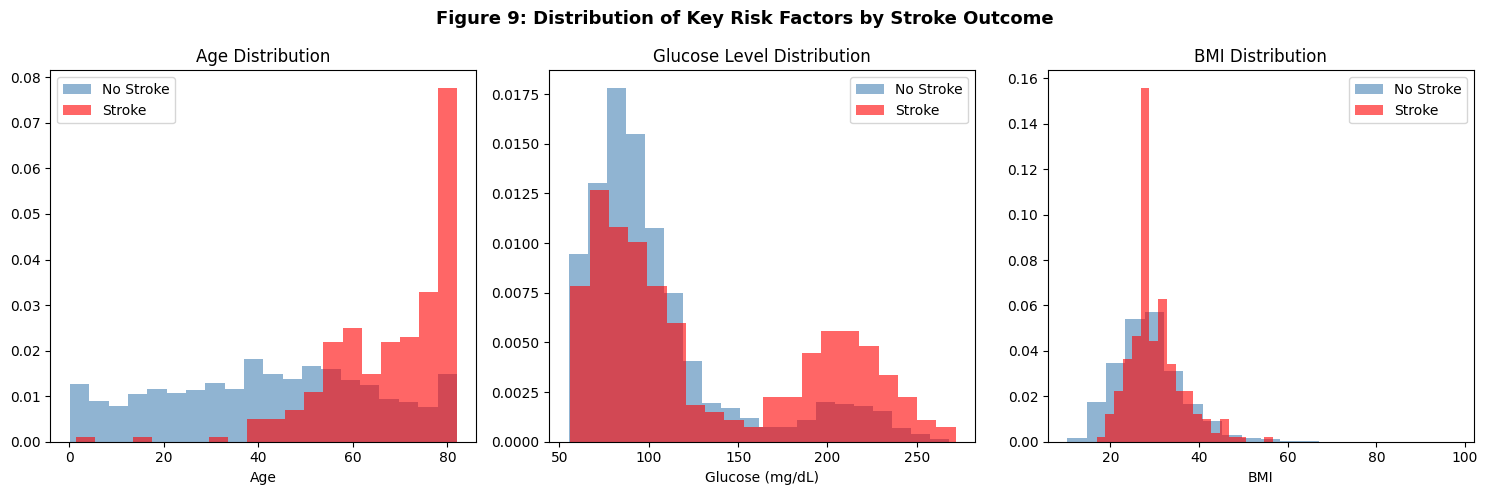

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age
axes[0].hist(df[df['stroke_event']==0]['age'], bins=20, alpha=0.6,
             color='steelblue', label='No Stroke', density=True)
axes[0].hist(df[df['stroke_event']==1]['age'], bins=20, alpha=0.6,
             color='red', label='Stroke', density=True)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

# Glucose
axes[1].hist(df[df['stroke_event']==0]['glucose_level'], bins=20, alpha=0.6,
             color='steelblue', label='No Stroke', density=True)
axes[1].hist(df[df['stroke_event']==1]['glucose_level'], bins=20, alpha=0.6,
             color='red', label='Stroke', density=True)
axes[1].set_title('Glucose Level Distribution')
axes[1].set_xlabel('Glucose (mg/dL)')
axes[1].legend()

# BMI
axes[2].hist(df[df['stroke_event']==0]['bmi_value'], bins=20, alpha=0.6,
             color='steelblue', label='No Stroke', density=True)
axes[2].hist(df[df['stroke_event']==1]['bmi_value'], bins=20, alpha=0.6,
             color='red', label='Stroke', density=True)
axes[2].set_title('BMI Distribution')
axes[2].set_xlabel('BMI')
axes[2].legend()

plt.suptitle('Figure 9: Distribution of Key Risk Factors by Stroke Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_risk_profiles.png', dpi=150)
plt.show()